# 📏 Unidad 1: Física de la Imagen
## Tema: Muestreo y Cuantización

¡Hola de nuevo! 👋

En la presentación vimos que para pasar del mundo real (analógico y suave) al mundo digital (cuadriculado), necesitamos hacer dos procesos:

1.  **Muestreo (Sampling):** Decidir cuántos cuadritos (píxeles) vamos a usar. Tiene que ver con la **Resolución Espacial**.
2.  **Cuantización:** Decidir cuántos colores o tonos de gris distintos podemos usar. Tiene que ver con la **Profundidad de Bits**.

Vamos a experimentar con esto.

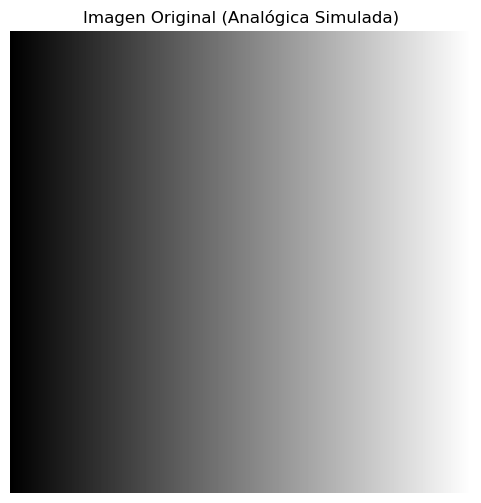

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Vamos a generar una imagen sintética: Un degradado suave (una rampa)
# Imagina una rampa de patinaje que va de oscuro a claro suavemente.
ancho = 256
alto = 256

# Creamos una matriz donde las columnas van de 0 a 255
imagen_original = np.tile(np.arange(256, dtype=np.uint8), (256, 1))

plt.figure(figsize=(6, 6))
plt.title("Imagen Original (Analógica Simulada)")
plt.imshow(imagen_original, cmap='gray')
plt.axis('off')
plt.show()

### 1. El Muestreo (Resolución Espacial)

Imagina que tienes que copiar una obra de arte, pero lo haces usando mosaicos (azulejos). Si usas azulejos muy grandes, pierdes detalle.

Esto se relaciona con el **Teorema de Nyquist**: Si muestreamos muy poco, la imagen se ve "pixeleada" o cuadrada.

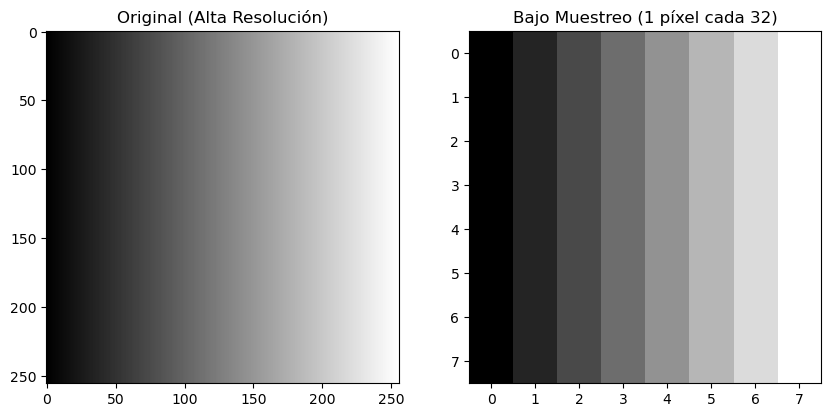

In [2]:
# Vamos a simular un BAJO MUESTREO (Downsampling)
# Vamos a quedarnos solo con 1 pixel de cada 32 pixeles.
factor_salto = 32 

# Tomamos filas y columnas saltando de 32 en 32
imagen_muestreada = imagen_original[::factor_salto, ::factor_salto]

plt.figure(figsize=(10, 5))

# Mostramos la original
plt.subplot(1, 2, 1)
plt.title("Original (Alta Resolución)")
plt.imshow(imagen_original, cmap='gray')

# Mostramos la 'pixeleada'
plt.subplot(1, 2, 2)
plt.title(f"Bajo Muestreo (1 píxel cada {factor_salto})")
# 'nearest' hace que se vean los cuadros marcados
plt.imshow(imagen_muestreada, cmap='gray', interpolation='nearest') 

plt.show()

### 2. La Cuantización (Profundidad de Bits)

Ahora imagina que vas a pintar un atardecer que tiene miles de tonos de naranja, pero en tu caja de colores solo tienes **4 crayolas**.

Eso es reducir la cuantización. Pasamos de 8 bits (256 colores) a, por ejemplo, 2 bits (4 colores).
Verás que aparecen líneas raras llamadas **Falsos Contornos**.

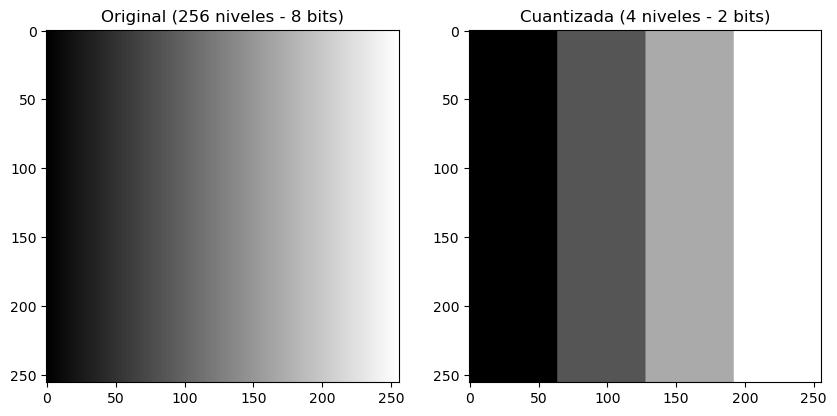

In [3]:
# Vamos a reducir los niveles de gris.
# En lugar de 0-255 continuo, forzaremos a que haya saltos grandes.

niveles = 4 # Imagina que solo tenemos 4 tonos de gris

# Matemáticas de cuantización: 
# Dividimos por un factor grande, redondeamos (floor) y volvemos a multiplicar.
factor_div = 256 // niveles
imagen_cuantizada = (imagen_original // factor_div) * factor_div

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original (256 niveles - 8 bits)")
plt.imshow(imagen_original, cmap='gray')

plt.subplot(1, 2, 2)
plt.title(f"Cuantizada ({niveles} niveles - 2 bits)")
plt.imshow(imagen_cuantizada, cmap='gray')

plt.show()

### Reflexión

¿Ves esas bandas verticales en la imagen de la derecha? Eso pasa cuando la computadora no tiene suficientes bits para representar cambios suaves de luz. 

* **Muestreo** afecta el **detalle** (borroso vs nítido).
* **Cuantización** afecta los **tonos** (suave vs bandas).